# **Import packages**

In [ ]:
import math
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import itertools

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

# **Dataset**

201

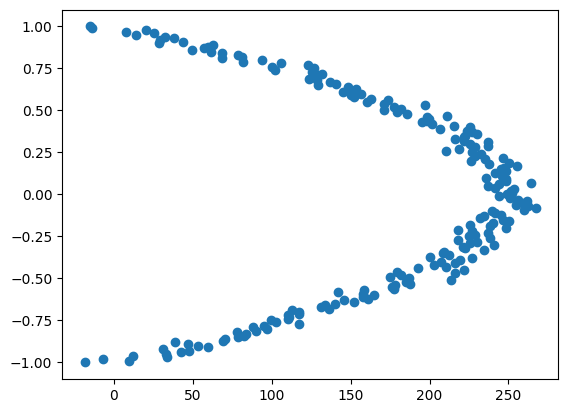

In [ ]:
R=1
r=np.arange(-1,1.01,0.01)
G=1
mu=0.001
u=G/(4*mu)*(R**2-r**2)+10*np.random.randn(len(r))
plt.scatter(u,r)
r=torch.tensor(r)
u=torch.tensor(u)
len(r)

# **Split the data set**

In [ ]:
val_ratio=0.2
n_sample=len(r)
shuffle_ind=torch.randperm(len(r))
train_ind=shuffle_ind[:-int(val_ratio*n_sample)]
val_ind=shuffle_ind[-int(val_ratio*n_sample):]
train_set_r=r[train_ind]
train_set_r=r[train_ind].unsqueeze(1)
train_set_u=u[train_ind].unsqueeze(1)
val_set_r=r[val_ind].unsqueeze(1)
val_set_u=u[val_ind].unsqueeze(1)

train_set_r=train_set_r.to(torch.float32)
train_set_u=train_set_u.to(torch.float32)
val_set_r=val_set_r.to(torch.float32)
val_set_u=val_set_u.to(torch.float32)

# **Model**


> Creating a fully connected network with adjustable depth, width, and activation function



In [ ]:
''' Homework!!! You have to fill the number in this block to achieve basic grade '''
#Attention! XX1 in first layer is identical in second layer, so as XX2 XX3 XX4
#suggest all XX range from 1~600, and gradually diverge then converge
def create_model(width, depth, activation):
    layers = []
    layers.append(nn.Linear(1, width))
    layers.append(activation())
    ''' Homework!!! You can add more layer to let the model deeper,
    withder or changing activate function to achieve intermediate level '''
    for _ in range(depth - 2):  # Inner layers
        layers.append(nn.Linear(width, width))
        layers.append(activation())
    layers.append(nn.Linear(width, 1))  # Output layer
    return nn.Sequential(*layers)

# **Hyperparameters**

In [ ]:
param_grid = {
    'width': [100, 200, 300, 400, 500, 600],
    'depth': [3, 4, 5],
    'activation': [nn.Tanh, nn.ReLU]
}

# **Loss function**

In [ ]:
loss_fn=nn.MSELoss()

# **Configuration**

In [ ]:
''' Homework!!! You have to fill the number in this block to achieve basic grade '''
lr=1e-4 # learning rate, suggest from 1e-3 to 1e-5
n_epoch=30000 # number of epoch, suggest from 10000 to 100000
best_loss=100000 #initial best loss, suggest large enogh like 100000

# **Training loop**


> Try different combinations of hyperparameters with the grid search. If validation loss is lower than best validation loss, update the best validation loss and store the network weights.



In [ ]:
# Intermediate & Advanced level
def train_with_grid_search(z_train, u_train, z_val, u_val, param_grid):
    results = []
    combinations = list(itertools.product(*param_grid.values()))

    best_loss_dict = {i: float(best_loss) for i in range(len(combinations))}
    best_model_dict = {}

    for i, combo in enumerate(combinations):
        width, depth, activation = combo
        print(f"Training with: Width={width}, Depth={depth}, Activation={activation.__name__}")

        model = create_model(width, depth, activation)
        optimizer = optim.SGD(model.parameters(), lr=lr)

        for epoch in range(1, n_epoch + 1):
            model.train()
            optimizer.zero_grad()
            u_p = model(z_train)
            train_loss = loss_fn(u_p, u_train)
            train_loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                u_v = model(z_val)
                val_loss = loss_fn(u_v, u_val)

            if val_loss < best_loss_dict[i]:
                best_loss_dict[i] = val_loss
                best_model_dict[i] = model.state_dict()
                ckpt_path = f"best_model_{width}_{depth}_{activation.__name__}.ckpt"
                torch.save(best_model_dict[i], ckpt_path)
                if epoch % 100 == 0:
                  print(f"Epoch {epoch} complete for combination (Width={width}, Depth={depth}, Activation={activation.__name__}): New best validation loss {val_loss.item():.4f}, training loss {train_loss.item():.4f}")

        results.append({
            'width': combo[0],
            'depth': combo[1],
            'activation': combo[2].__name__,
            'best_val_loss': best_loss_dict[i]
        })

    return results

In [ ]:
results = train_with_grid_search(train_set_r, train_set_u, val_set_r, val_set_u, param_grid)

Training with: Width=100, Depth=3, Activation=Tanh
Epoch 100 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 7025.2188, training loss 6294.0103
Epoch 200 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 6185.6392, training loss 5060.0552
Epoch 300 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 1922.8721, training loss 1587.1324
Epoch 400 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 612.8666, training loss 452.0989
Epoch 500 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 374.1666, training loss 271.7523
Epoch 600 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 297.3820, training loss 214.4243
Epoch 700 complete for combination (Width=100, Depth=3, Activation=Tanh): New best validation loss 252.7621, training loss 179.1241
Epoch 800 complete 

# **Heatmaps**


> Use heatmaps to represent the training effect of different width, depth and activation function.



In [ ]:
def plot_heatmaps(results):
    df = pd.DataFrame(results)

    df['best_val_loss'] = df['best_val_loss'].astype(float)

    # Loop through different activation functions and plot heatmaps
    for activation_fn in df['activation'].unique():
        df_subset = df[df['activation'] == activation_fn].pivot(index='depth', columns='width', values='best_val_loss')

        plt.figure(figsize=(8, 6))
        sns.heatmap(df_subset, annot=True, fmt=".4f", cmap='viridis')
        plt.title(f'Heatmap of Validation Loss for Activation Function: {activation_fn}')
        plt.xlabel('Width')
        plt.ylabel('Depth')
        plt.show()

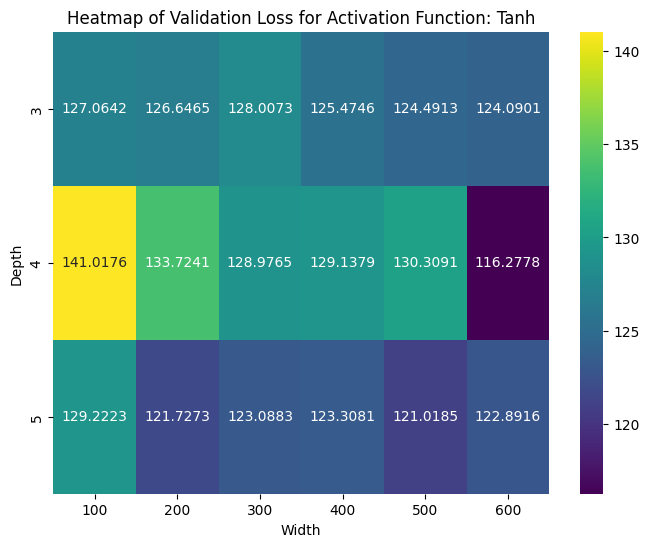

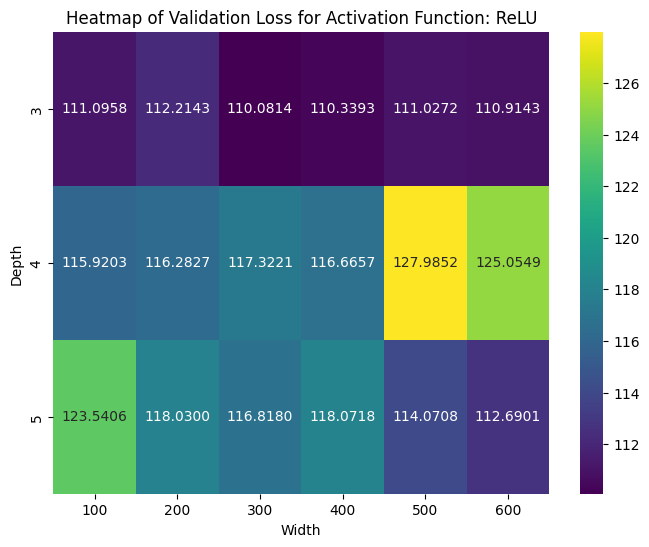

In [ ]:
plot_heatmaps(results)



---


> ***Here are the observations I gathered from the heatmap results:***

  When using the Tanh activation function, the overall validation loss is relatively high. However, increasing both the depth and width of the model effectively reduces the validation loss. On the other hand, when using the ReLU activation function, increasing the model depth has little to no effect on reducing validation loss, and the benefits of increasing model width are also limited.

> ***In my opinion...***

  When using the Tanh activation function, the overall validation loss tends to be higher, and increasing both model depth and width helps reduce this loss. This may be related to the nature of the Tanh function, as its output range lies between -1 and 1, resulting in smoother outputs. However, this could also lead to the vanishing gradient problem, where shallow networks struggle to learn more complex features effectively. Thus, increasing depth is necessary to capture more non-linear relationships. Additionally, increasing the model width helps improve performance by allowing the network to learn more features and patterns. In particular, with the Tanh activation function, a wider network can mitigate the vanishing gradient effect by providing more capacity to learn.

  On the other hand, with the ReLU activation function, the model performs better overall, and increasing the depth has limited impact on reducing validation loss. This is likely because ReLU naturally handles the vanishing gradient problem better, especially in shallower networks where it learns more efficiently. Therefore, adding more depth does not significantly improve the model’s performance. Similarly, increasing width also provides limited benefit. This is likely because, under the ReLU activation, a network with a relatively smaller width is already capable of capturing enough features. As a result, moderate width seems sufficient to fully capture the dataset's characteristics, and further increasing width brings minimal improvement.

  In summary, models using the Tanh activation function rely more on both depth and width to reduce loss, whereas models using ReLU perform better with shallower and moderately wide architectures due to its effectiveness in addressing the gradient issue.


---



# **Show the result**


> Show the best combination of hyperparameters!!! Create a model based on the results and load the model weights.



In [ ]:
best_result = min(results, key=lambda x: x['best_val_loss'])
best_model_path = f"best_model_{best_result['width']}_{best_result['depth']}_{best_result['activation']}.ckpt"
best_model = create_model(best_result['width'], best_result['depth'], getattr(nn, best_result['activation']))
best_model.load_state_dict(torch.load(best_model_path, weights_only=True))

print(f"Best combination: Width={best_result['width']}, Depth={best_result['depth']}, Activation={best_result['activation']}")
print(f"Best validation loss: {best_result['best_val_loss']:.4f}")

Best combination: Width=300, Depth=3, Activation=ReLU
Best validation loss: 110.0814


# **Plot the result**

Text(0, 0.5, 'r radius (m)')

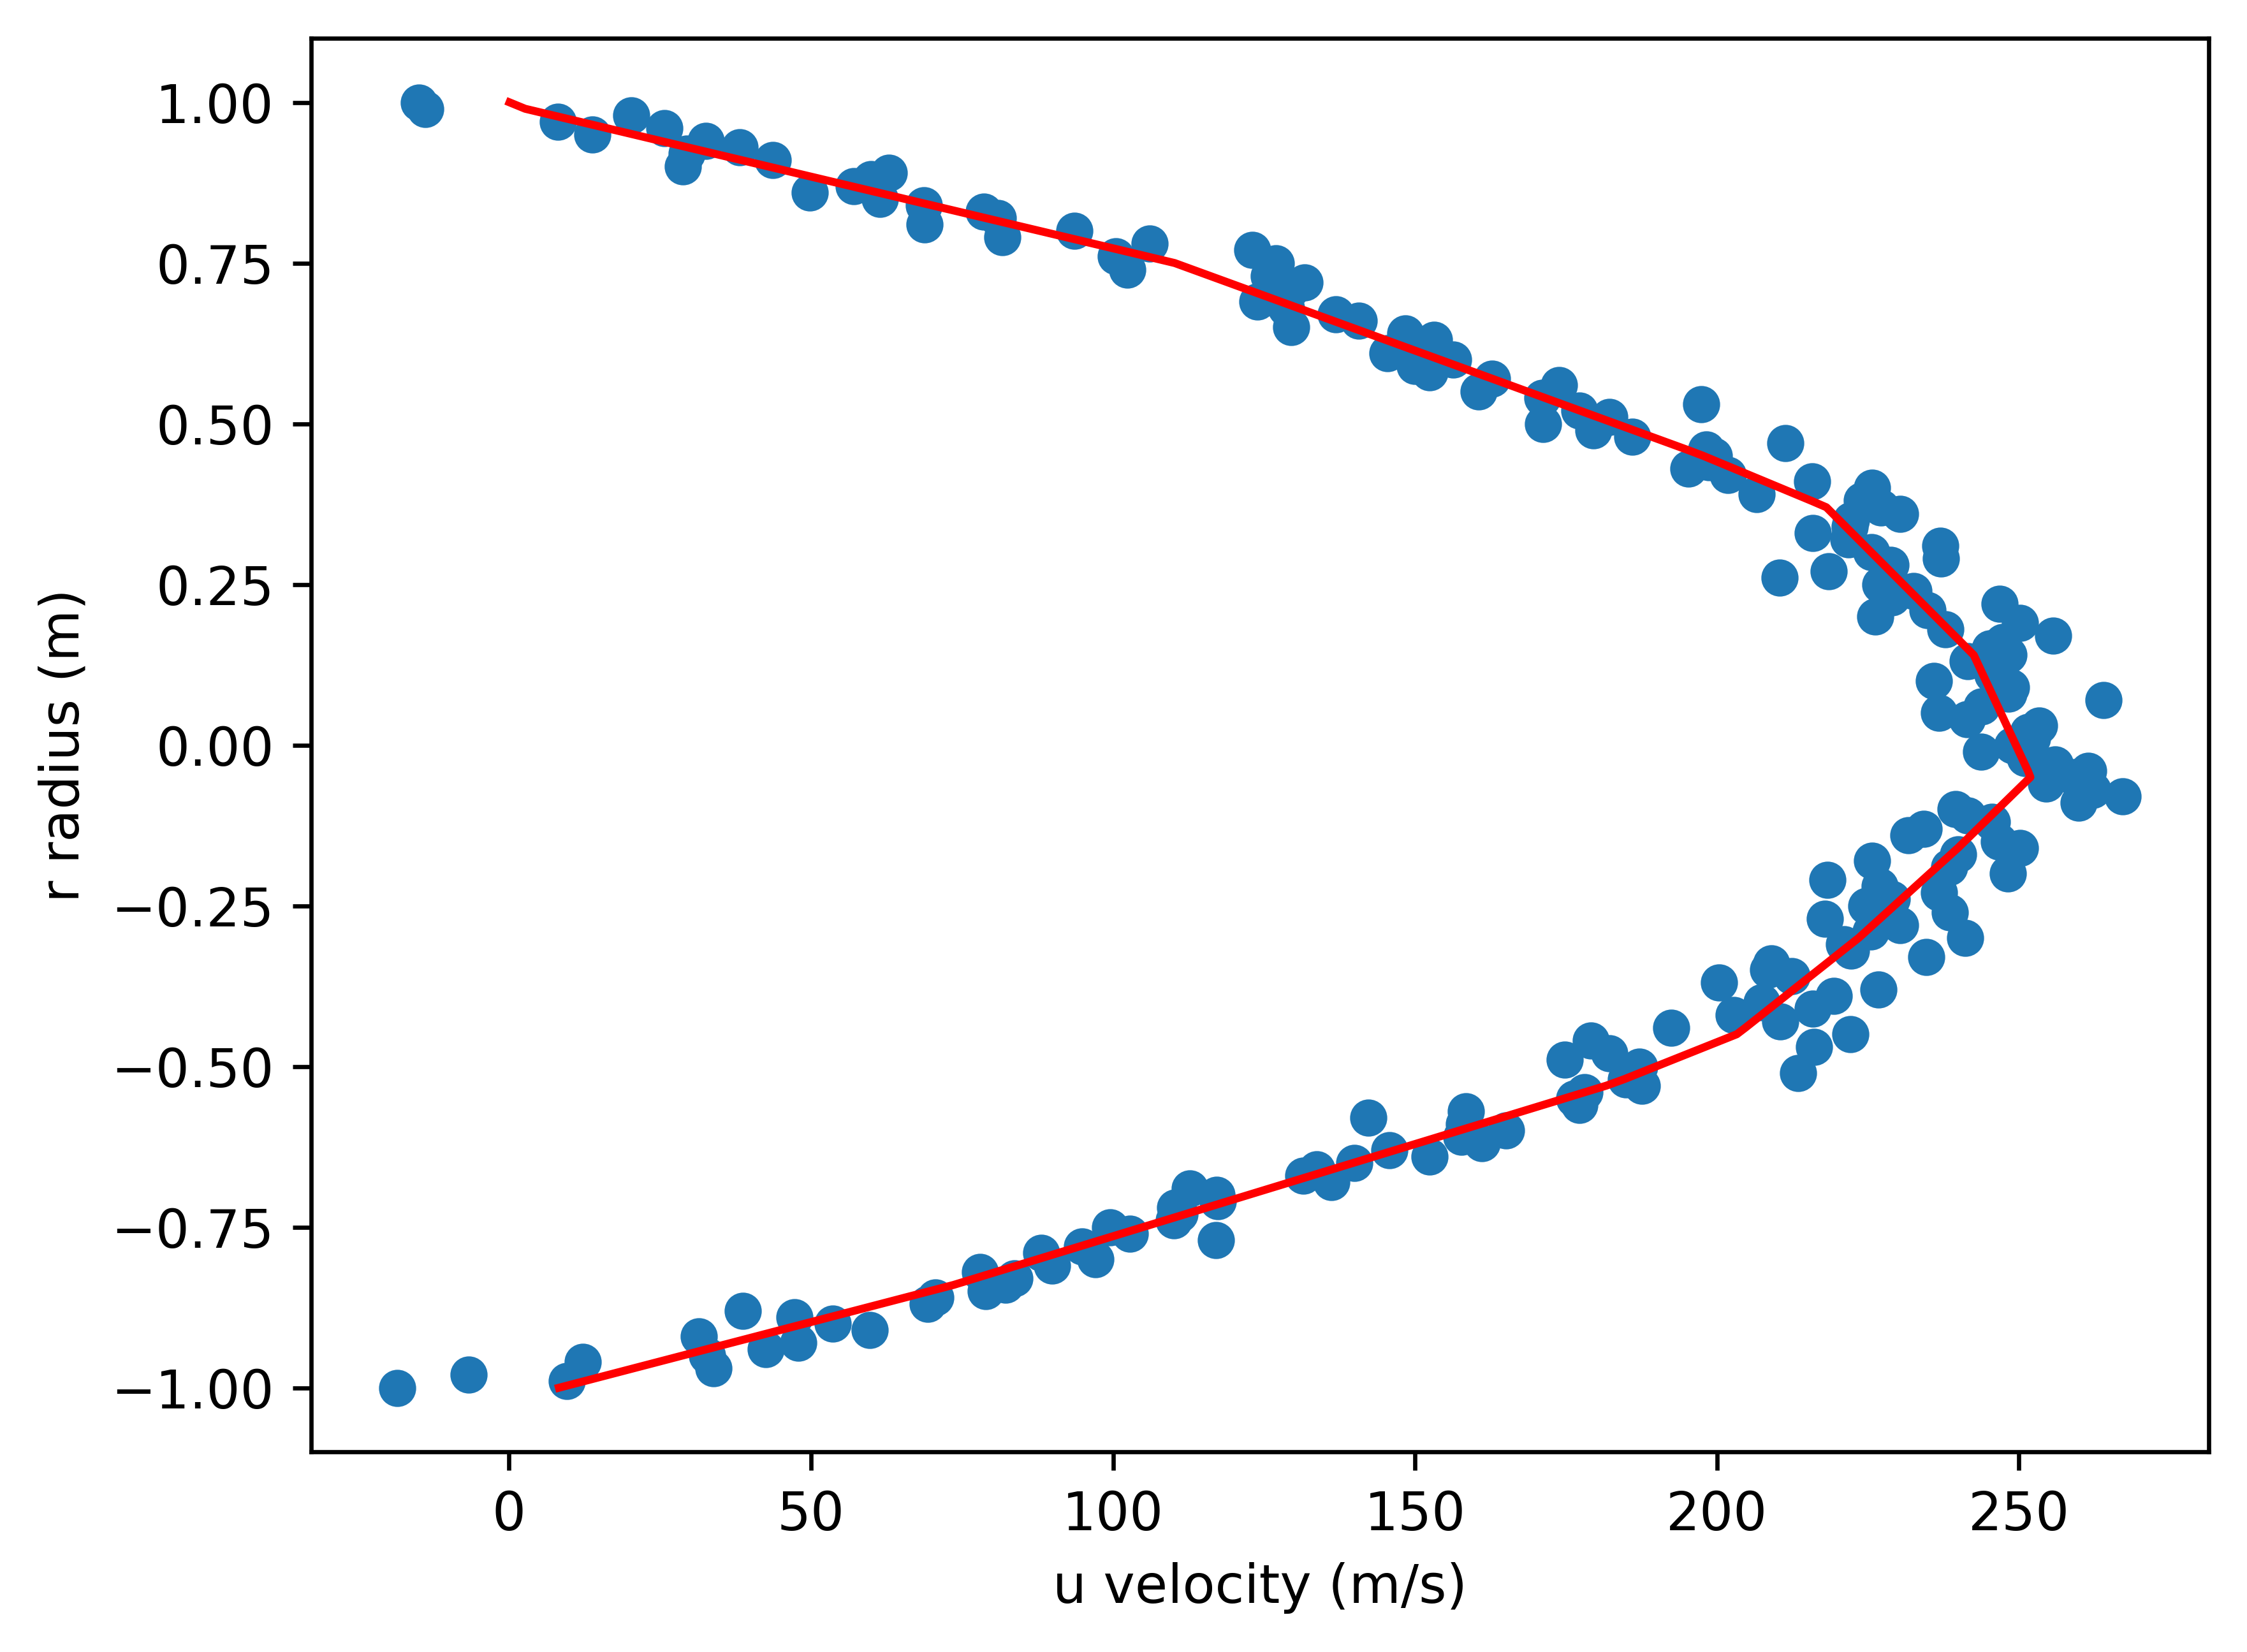

In [ ]:
r=np.arange(-1,1.01,0.01)
r=torch.tensor(r).unsqueeze(1)
r=r.to(torch.float32)
u_p=best_model(r)

fig=plt.figure(dpi=600)
plt.plot(u.numpy(),r.numpy(),'o')
plt.plot(u_p.detach().numpy(),r.numpy(),'r-')
plt.xlabel("u velocity (m/s)")
plt.ylabel("r radius (m)")